In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)

dir.create("../figures", showWarnings = FALSE)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'ggplot2' was built under R version 4.3.3"


## Load cleaned data

In [2]:
bls <- read.csv("../cleaned_data/bls_data.csv") %>% mutate(date = as.Date(date))
fed <- read.csv("../cleaned_data/fedfunds_data.csv") %>% mutate(date = as.Date(date))
gdp <- read.csv("../cleaned_data/gdp_data.csv") %>%mutate(date = as.Date(date))

---
## Summary table — state-level descriptive statistics

In [3]:
summary_tbl <- bls %>%
  group_by(state) %>%
  summarise(
    mean = round(mean(unemployment_rate), 2),
    sd   = round(sd(unemployment_rate),   2),
    min  = round(min(unemployment_rate),  1),
    max  = round(max(unemployment_rate),  1),
    .groups = "drop"
  ) %>%
  arrange(desc(sd))

print('Top 10 most volatile states')
print(head(summary_tbl, 10))

print('Top 10 least volatile states')
print(tail(summary_tbl, 10))

[1] "Top 10 most volatile states"
# A tibble: 10 x 5
   state  mean    sd   min   max
   <chr> <dbl> <dbl> <dbl> <dbl>
 1 MI     7.57  3.08   3.2  22.7
 2 WV     7.66  3.01   3.5  18.3
 3 NV     6.59  2.76   3.9  30.5
 4 AL     6.6   2.67   2.3  14.7
 5 RI     6.25  2.38   2.6  17.9
 6 IN     5.79  2.35   2.7  16.9
 7 LA     6.82  2.21   3.5  13.5
 8 OH     6.46  2.18   3.4  16.5
 9 CA     7.1   2.16   3.8  16.1
10 TN     6.06  2.16   3.1  15.7
[1] "Top 10 least volatile states"
# A tibble: 10 x 5
   state  mean    sd   min   max
   <chr> <dbl> <dbl> <dbl> <dbl>
 1 TX     5.87  1.47   3.4  12.8
 2 OK     4.82  1.46   2.9  12.5
 3 MD     5.05  1.44   1.9   9  
 4 MN     4.66  1.44   2.3  11.1
 5 WY     4.75  1.44   2.4   8.9
 6 VA     4.49  1.36   2.2  11.9
 7 KS     4.51  1.1    2.5  12.1
 8 ND     3.65  1.05   1.9   8.7
 9 SD     3.48  0.92   1.7   8.8
10 NE     3.39  0.89   2     8.2


# Big Shocks and How Each State Reacted

In [4]:
important_states <- c("CA", "TX", "MI", "NV", "ND", "NY", "OH", "FL", "IL", "PA")

disruptions <- list(
  "Volcker 1980-82" = c("1980-01-01", "1982-12-01"),
  "GFC 2008-09" = c("2008-01-01", "2009-12-01"),
  "COVID 2020" = c("2020-01-01", "2020-12-01")
)

for (disruption in names(disruptions)) {
  time_frame <- disruptions[[disruption]]
  state_peaks <- bls %>%
    filter(date >= as.Date(time_frame[1]),
           date <= as.Date(time_frame[2]),
           state %in% important_states) %>%
    group_by(state) %>%
    summarise(peak_ur = max(unemployment_rate),
              mean_ur = round(mean(unemployment_rate), 1),
              .groups = "drop") %>%
    arrange(desc(peak_ur))

  nat_peak <- bls %>%
    filter(date >= as.Date(time_frame[1]),
           date <= as.Date(time_frame[2])) %>%
    group_by(date) %>%
    summarise(mean_ur = mean(unemployment_rate), .groups = "drop") %>%
    pull(mean_ur) %>%
    max() %>%
    round(1)

  fed_range <- fed %>%
    filter(date >= as.Date(time_frame[1]),
           date <= as.Date(time_frame[2])) %>%
    summarise(lo = round(min(fed_rate), 1),
              hi = round(max(fed_rate), 1))

  gdp_min <- gdp %>%
    filter(date >= as.Date(time_frame[1]),
           date <= as.Date(time_frame[2])) %>%
    pull(gdp_growth) %>%
    min() %>%
    round(1)

  cat("Disruption:", disruption, "\n")
  cat("National peak UR:", nat_peak, "%\n")
  cat("Fed rate range:  ", fed_range$lo, "% to", fed_range$hi, "%\n")
  cat("GDP growth trough:", gdp_min, "%\n\n")
  print(state_peaks)
}

Disruption: Volcker 1980-82 
National peak UR: 10.1 %
Fed rate range:   8.9 % to 19.1 %
GDP growth trough: -8 %

# A tibble: 10 x 3
   state peak_ur mean_ur
   <chr>   <dbl>   <dbl>
 1 MI       16.5    13.3
 2 OH       14      10.2
 3 IL       12.9     9.4
 4 PA       12.2     9.1
 5 NV       11.2     7.9
 6 CA       11.1     8.1
 7 NY        9.5     7.9
 8 FL        9.4     7.1
 9 TX        8.3     5.8
10 ND        6.2     5.1
Disruption: GFC 2008-09 
National peak UR: 9 %
Fed rate range:   0.1 % to 3.9 %
GDP growth trough: -8.5 %

# A tibble: 10 x 3
   state peak_ur mean_ur
   <chr>   <dbl>   <dbl>
 1 MI       14.3    10.9
 2 NV       12.7     9  
 3 CA       12.3     9.4
 4 FL       11.3     8.3
 5 IL       11.2     8.2
 6 OH       10.7     8.4
 7 NY        9       6.9
 8 TX        8.4     6.2
 9 PA        8.3     6.7
10 ND        4       3.5
Disruption: COVID 2020 
National peak UR: 13.7 %
Fed rate range:   0 % to 1.6 %
GDP growth trough: -28 %

# A tibble: 10 x 3
   state peak_ur 

# Figure 1: Average Unemployment Rate overtime

Saving 7 x 7 in image


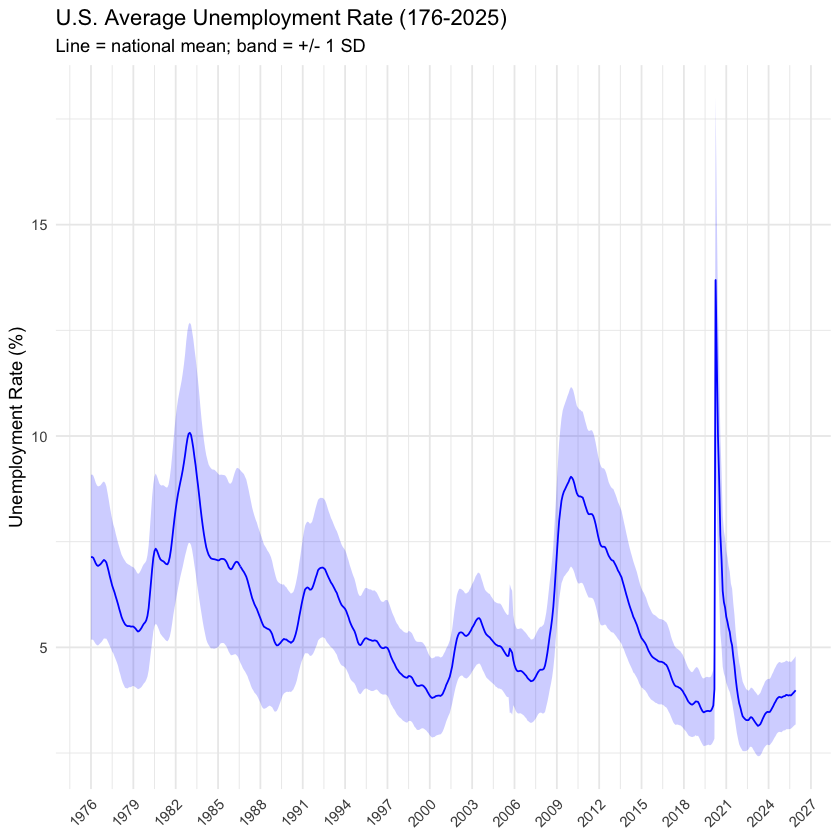

In [5]:
national <- bls %>%
  group_by(date) %>%
  summarise(
    mean_ur = mean(unemployment_rate),
    sd_ur = sd(unemployment_rate)
  )
  
fig1 <- ggplot(national, aes(x = date)) +
  geom_ribbon(aes(ymin = mean_ur - sd_ur, ymax = mean_ur + sd_ur),
              fill = "blue", alpha = 0.2) +
  geom_line(aes(y = mean_ur), colour = "blue") +
  scale_x_date(date_breaks = "3 years", date_labels = "%Y") +
  labs(
    title = "U.S. Average Unemployment Rate (176-2025)",
    subtitle = "Line = national mean; band = +/- 1 SD",
    x = NULL, y = "Unemployment Rate (%)"
  ) +
  theme_minimal(base_size = 11) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

fig1
ggsave("../figures/fig1_national.pdf", fig1)

# Figure 2: Covariates over time

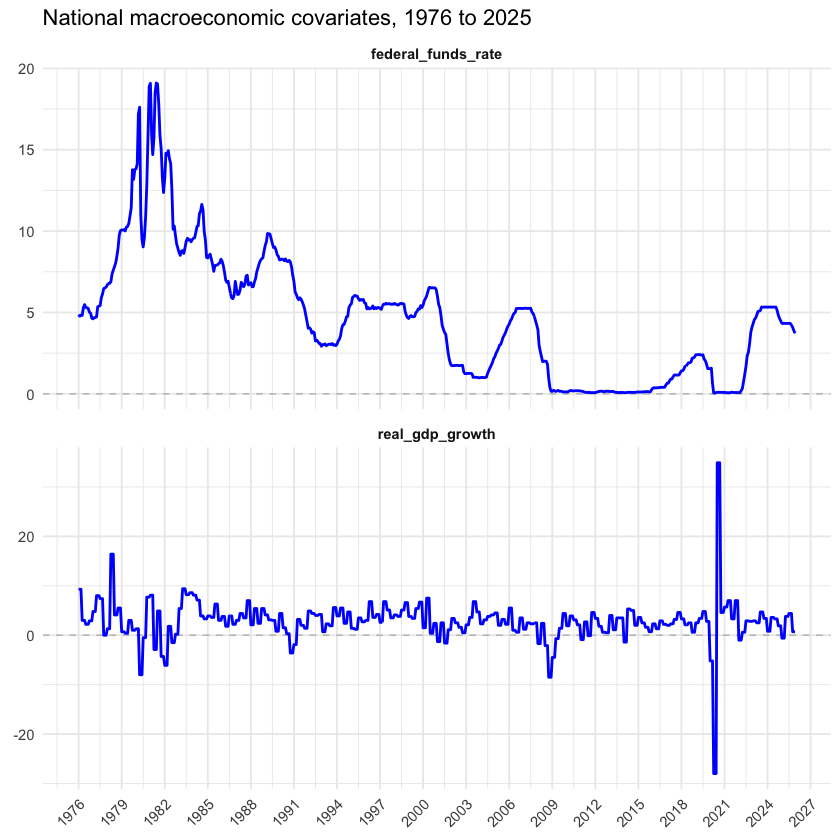

In [6]:
covs <- bind_rows(
  fed %>% mutate(series = "federal_funds_rate", value = fed_rate) %>% select(date, series, value),
  gdp %>% mutate(series = "real_gdp_growth", value = gdp_growth) %>% select(date, series, value)
)

covs$series <- factor(covs$series,
                            levels = c("federal_funds_rate",
                                       "real_gdp_growth"))

fig3 <- ggplot(covs, aes(x = date, y = value)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey", linewidth = 0.4) +
  geom_line(colour = "blue", linewidth = 0.8) +
  facet_wrap(~series, ncol = 1, scales = "free_y") +
  scale_x_date(date_breaks = "3 years", date_labels = "%Y") +
  labs(
    title = "National macroeconomic covariates, 1976 to 2025",
    x = NULL, y = NULL
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(face = "bold")
  )

fig3
ggsave("../figures/fig3_covariates.pdf", fig3, width = 8, height = 5)